# Training a KIND filter on simulated cavity data

KIND model can be trained as a filter to differentiate between stationary and transient cavity data.

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import ex_detuning
import util_data

### KIND model training

We train only the mean of a stationary operator. This suffices to determine the stationary of data in this context.

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/kalman',
        '--file_name', 'detuning_sim',
        '--data_nsample', '500',
        '--feature_ndim', '3',
        '--target_ndim', '1',

        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '32',
        '--nepoch', '100',
        '--patience', '10',
        '--checkpoints', '../../models/kalman/filter',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 5, "cos": 5}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
        '--nneuron_stat', '64',
        '--nlayer_stat', '2',
    ]
)

In [3]:
model = kind.model(args)

dataset = ex_detuning.dataset_synthetic(
    args.file_dir, args.file_name, args.file_ext,
    args.data_nsample,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample)
)

In [4]:
model.train()
model.fit(dataset)

>>> train nominal mean >>>
	epoch 1 losses: train=1.493496, valid=0.084672, test=0.084891
	validation loss decreased (inf -> 0.084672), saving model ...
	epoch 2 losses: train=0.726856, valid=0.067150, test=0.066777
	validation loss decreased (0.084672 -> 0.067150), saving model ...
	epoch 3 losses: train=0.700092, valid=0.070606, test=0.070701
	early stopping counter: 1 out of 10
	epoch 4 losses: train=0.499216, valid=0.035365, test=0.037304
	validation loss decreased (0.067150 -> 0.035365), saving model ...
	epoch 5 losses: train=0.257718, valid=0.023160, test=0.024782
	validation loss decreased (0.035365 -> 0.023160), saving model ...
	epoch 6 losses: train=0.236505, valid=0.020310, test=0.022142
	validation loss decreased (0.023160 -> 0.020310), saving model ...
	epoch 7 losses: train=0.229197, valid=0.019462, test=0.021255
	validation loss decreased (0.020310 -> 0.019462), saving model ...
	epoch 8 losses: train=0.226217, valid=0.019393, test=0.021003
	validation loss decreased (0

### KIND model evaluation

In [6]:
# --! evaluate trained model --!

model.eval()
_, _, data_loader = dataset.load(data_type='nom')

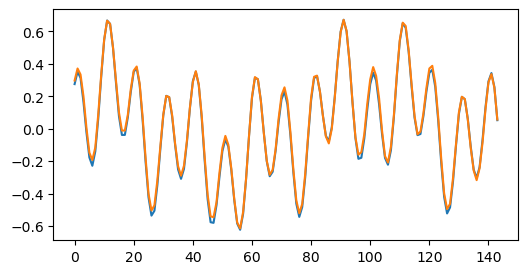

In [7]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break